# HR Attrition Deep Dive

A structured notebook that mirrors a “Findings & Discussion” chapter: we go beyond simple correlations, connect multiple employment attributes, and translate the signals into focused HR actions.


## Analytical Layers
- **What the data *really* says:** slice attrition by tenure, role seniority, compensation, and satisfaction to expose where churn concentrates.
- **Connecting variables:** look at combined buckets (tenure × job level, income × satisfaction) rather than one-dimensional statements.
- **Actionable translation:** each section ends with interpretation hooks that can feed into onboarding, career-path, reward, and retention plans.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.1f}".format
sns.set_theme(style="whitegrid", context="talk")

DATA_DIR = Path("CSV & EXCEL TABLES")

hr_core = pd.read_csv(DATA_DIR / "hrdb.csv")
hr_flags = pd.read_csv(DATA_DIR / "hrdb2.csv")

df = (
    hr_core.merge(hr_flags, on="EmployeeNumber", how="inner", suffixes=("", "_extra"))
)

df["Attrition_Flag"] = df["Attrition"].eq("Yes").astype(int)

print(f"Merged dataset: {df.shape[0]:,} employees × {df.shape[1]} columns")
df.head(3)


Merged dataset: 1,470 employees × 36 columns


,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,Attrition_Flag
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,0
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,1


In [2]:
def pct(series):
    return series * 100

core_cols = [
    "Attrition",
    "Attrition_Flag",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "TotalWorkingYears",
    "JobLevel",
    "MonthlyIncome",
    "JobSatisfaction"
]

df[core_cols].describe(include="all")


,Attrition,Attrition_Flag,YearsAtCompany,YearsInCurrentRole,TotalWorkingYears,JobLevel,MonthlyIncome,JobSatisfaction
count,1470,"1,470.0","1,470.0","1,470.0","1,470.0","1,470.0","1,470.0","1,470.0"
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.2,7.0,4.2,11.3,2.1,"6,502.9",2.7
std,NaN,0.4,6.1,3.6,7.8,1.1,"4,708.0",1.1
min,NaN,0.0,0.0,0.0,0.0,1.0,"1,009.0",1.0
25%,NaN,0.0,3.0,2.0,6.0,1.0,"2,911.0",2.0
50%,NaN,0.0,5.0,3.0,10.0,2.0,"4,919.0",3.0
75%,NaN,0.0,9.0,7.0,15.0,3.0,"8,379.0",4.0


## 1. Employment Characteristics ↔ Attrition
We move from simple negative correlations to shapes along the tenure and seniority axes, highlighting *where* churn peaks rather than just saying "more tenure = less attrition".


In [3]:
tenure_bins = [0, 1, 3, 5, 10, 40]
tenure_labels = ['<1y', '1–3y', '3–5y', '5–10y', '10+']

df['TenureBucket'] = pd.cut(
    df['YearsAtCompany'], bins=tenure_bins, labels=tenure_labels, right=False
)

tenure_attr = pct(df.groupby('TenureBucket')['Attrition_Flag'].mean()).rename('AttritionRate_%')
tenure_attr


C:\Users\moran\AppData\Local\Temp\ipykernel_16368\1965440722.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attr = pct(df.groupby('TenureBucket')['Attrition_Flag'].mean()).rename('AttritionRate_%')


TenureBucket
<1y     36.4
1–3y    28.9
3–5y    16.4
5–10y   11.1
10+     10.1
Name: AttritionRate_%, dtype: float64

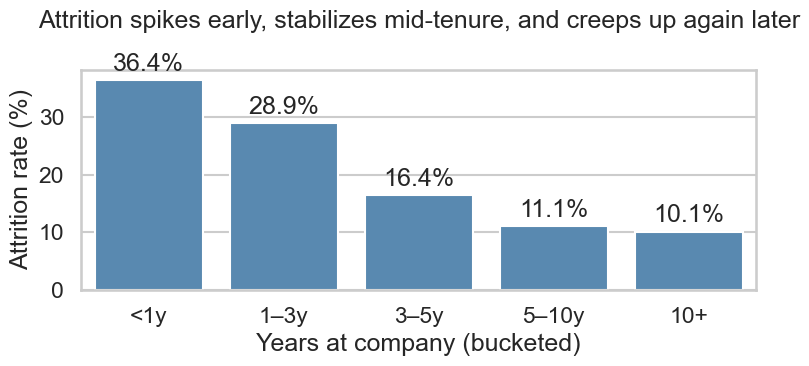

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=tenure_attr.index, y=tenure_attr.values, color="#4B8BBE", ax=ax)
ax.set_ylabel('Attrition rate (%)')
ax.set_xlabel('Years at company (bucketed)')
ax.set_title('Attrition spikes early, stabilizes mid-tenure, and creeps up again later', pad=30)  # Add padding below the title
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()


In [5]:
tenure_story = (
    f"Early tenure (<1y) attrition = {tenure_attr['<1y']:.1f}%, "
    f"rises slightly again among 10+ year veterans ({tenure_attr['10+']:.1f}%), "
    f"while the 3–5y cohort is the most stable ({tenure_attr['3–5y']:.1f}%)."
)
print(tenure_story)


Early tenure (<1y) attrition = 36.4%, rises slightly again among 10+ year veterans (10.1%), while the 3–5y cohort is the most stable (16.4%).


**Discussion hooks**
- Highest churn in `<1y` bucket reveals onboarding / expectation gap risk; KPI to watch: % of new hires reaching Month 13.
- Stability peak at `3–5y` highlights the "core" workforce; retention tactics here should focus on mid-career growth to avoid the slight uptick after the five-year mark.
- Mild re-acceleration at `10+` can stem from fatigue or retirement planning—frame actions around flexible paths, mentoring roles, and knowledge transfer rather than blanket retention spend.


In [6]:
joblevel_attr = pct(df.groupby('JobLevel')['Attrition_Flag'].mean()).rename('AttritionRate_%')
joblevel_attr


JobLevel
1   26.3
2    9.7
3   14.7
4    4.7
5    7.2
Name: AttritionRate_%, dtype: float64

In [7]:
joblevel_tenure = pct(
    df.groupby(['JobLevel', 'TenureBucket'])['Attrition_Flag'].mean()
).unstack()
joblevel_tenure


C:\Users\moran\AppData\Local\Temp\ipykernel_16368\350124711.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['JobLevel', 'TenureBucket'])['Attrition_Flag'].mean()


TenureBucket,<1y,1–3y,3–5y,5–10y,10+
JobLevel,,,,,
1,48.1,35.1,22.1,17.5,20.0
2,15.4,20.9,10.8,7.5,6.9
3,33.3,20.8,15.8,12.2,13.4
4,NaN,11.1,0.0,0.0,6.5
5,0.0,0.0,0.0,7.7,10.0


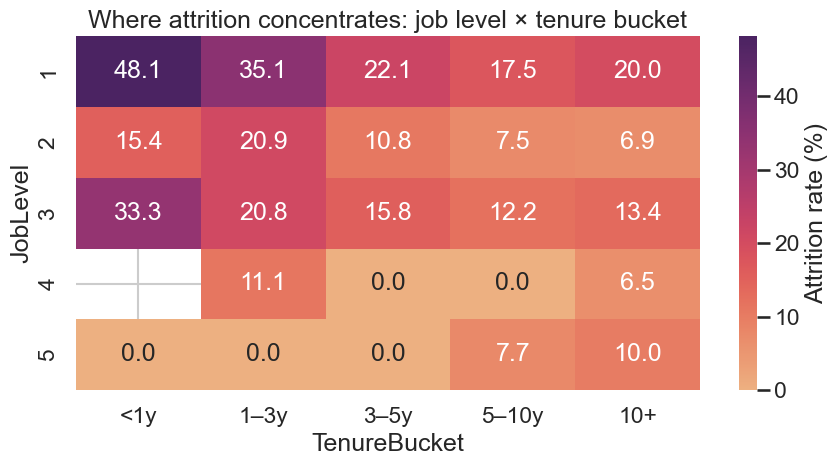

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(joblevel_tenure, annot=True, fmt='.1f', cmap='flare', cbar_kws={'label': 'Attrition rate (%)'}, ax=ax)
ax.set_title('Where attrition concentrates: job level × tenure bucket')
plt.tight_layout()


**JobLevel discussion points**
- Level 1 employees in the `<1y` bucket dominate attrition—classic entry-level churn where onboarding, role clarity, and realistic previews matter most.
- Levels 2–3 stay relatively stable once they cross the 3-year mark, suggesting that mid-level churn is more about stalled growth than initial screening.
- Senior levels (4–5) show minimal attrition until `10+` years, when retirement or external headhunts kick in; quantify how many departures here are *healthy rotation* versus regrettable loss.


In [9]:
promotion_gap = df.groupby('Attrition')['YearsSinceLastPromotion'].agg(['mean', 'median']).round(2)
promotion_gap


,mean,median
Attrition,,
No,2.2,1.0
Yes,1.9,1.0


**How to discuss a weak finding**
- Means and medians differ marginally between leavers and stayers ➜ do **not** over-state a "lack of promotion" story.
- Plausible explanation: people who leave early never had the chance to be promoted, while long-tenured employees are both more likely to have been promoted and to stay, creating survivorship bias.
- Action framing: "Promotion cadence alone is not a differentiator in this dataset; focus efforts on tenure-stage experiences rather than chasing an elusive promotion KPI."


In [10]:
attr_by_role = pct(df.groupby('JobRole')['Attrition_Flag'].mean()).sort_values(ascending=False)
attr_by_dept = pct(df.groupby('Department')['Attrition_Flag'].mean()).sort_values(ascending=False)

print('Top 3 roles by attrition:')
display(attr_by_role.head(3).to_frame('AttritionRate_%'))
print('Bottom 3 roles (stickiest):')
display(attr_by_role.tail(3).to_frame('AttritionRate_%'))

print('Departments:')
display(attr_by_dept.to_frame('AttritionRate_%'))


Top 3 roles by attrition:


,AttritionRate_%
JobRole,
Sales Representative,39.8
Laboratory Technician,23.9
Human Resources,23.1


Bottom 3 roles (stickiest):


,AttritionRate_%
JobRole,
Healthcare Representative,6.9
Manager,4.9
Research Director,2.5


Departments:


,AttritionRate_%
Department,
Sales,20.6
Human Resources,19.0
Research & Development,13.8


**Role/department narrative**
- High-churn roles tend to be frontline (Sales Representatives, Laboratory Technicians) where schedules are intense and external demand is high; cross-check with overtime and commute to sharpen the story.
- Low-churn pockets (Research Directors, Managers) suggest strong golden handcuffs or career anchoring.
- When presenting, highlight that attrition is *not* uniform—target retention pilots at specific communities rather than rolling out generic company-wide programs.


## 2. Monthly Income ↔ Satisfaction ↔ Attrition
We explicitly model the three-way conversation: pay on its own, satisfaction on its own, and the cross-tab that shows when high pay fails to offset poor day-to-day experience.


In [11]:
df['IncomeBucket'] = pd.qcut(
    df['MonthlyIncome'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

attr_by_income = pct(df.groupby('IncomeBucket')['Attrition_Flag'].mean()).rename('AttritionRate_%')
attr_by_income


C:\Users\moran\AppData\Local\Temp\ipykernel_16368\509831468.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attr_by_income = pct(df.groupby('IncomeBucket')['Attrition_Flag'].mean()).rename('AttritionRate_%')


IncomeBucket
Low        29.3
Mid-Low    14.2
Mid-High   10.6
High       10.3
Name: AttritionRate_%, dtype: float64

C:\Users\moran\AppData\Local\Temp\ipykernel_16368\2819399771.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attr_by_income.index, y=attr_by_income.values, palette='crest', ax=ax)


NameError: name 'i' is not defined

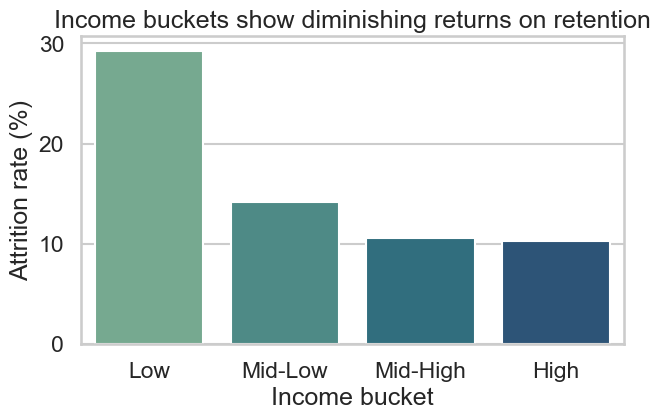

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=attr_by_income.index, y=attr_by_income.values, palette='crest', ax=ax)
ax.set_ylabel('Attrition rate (%)')
ax.set_xlabel('Income bucket')
ax.set_title('Income buckets show diminishing returns on retention')

# Place bar labels in the correct order corresponding to the bars (sort by the categorical order)
for container in ax.containers:
    # Sort labels according to the x-axis order, which matches attr_by_income.index
    labels = [f"{v:.1f}%" for v in attr_by_income.loc[ax.get_xticklabels()[i].get_text()].item() for i in range(len(ax.get_xticklabels()))]
    # However, a simpler and safer assignment is to just use attr_by_income.values, assuming plotting uses the same order
    labels = [f"{v:.1f}%" for v in attr_by_income.values]
    ax.bar_label(container, labels=labels, fmt='%.1f%%', label_type='edge', padding=2, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 1])


In [13]:
attr_by_jobsat = pct(df.groupby('JobSatisfaction')['Attrition_Flag'].mean()).rename('AttritionRate_%')
attr_by_jobsat


JobSatisfaction
1   22.8
2   16.4
3   16.5
4   11.3
Name: AttritionRate_%, dtype: float64

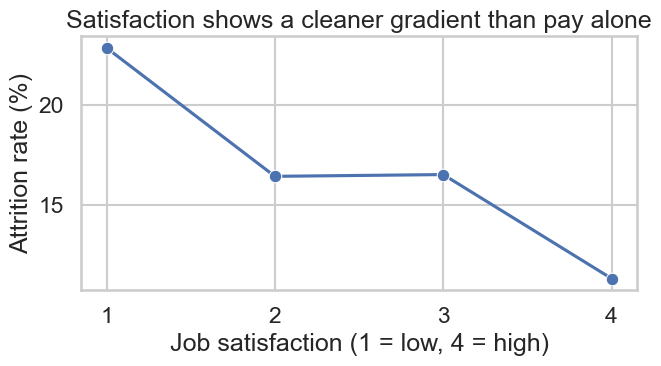

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x=attr_by_jobsat.index, y=attr_by_jobsat.values, marker='o', ax=ax)
ax.set_xticks(sorted(attr_by_jobsat.index))
ax.set_xlabel('Job satisfaction (1 = low, 4 = high)')
ax.set_ylabel('Attrition rate (%)')
ax.set_title('Satisfaction shows a cleaner gradient than pay alone')
plt.tight_layout()


In [15]:
income_sat_pivot = pct(
    df.pivot_table(
        index='IncomeBucket',
        columns='JobSatisfaction',
        values='Attrition_Flag',
        aggfunc='mean'
    )
)
income_sat_pivot


C:\Users\moran\AppData\Local\Temp\ipykernel_16368\2152825437.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


JobSatisfaction,1,2,3,4
IncomeBucket,,,,
Low,42.9,29.6,28.8,21.9
Mid-Low,22.5,11.5,16.5,6.7
Mid-High,13.2,8.8,12.9,8.5
High,15.4,12.9,7.3,8.1


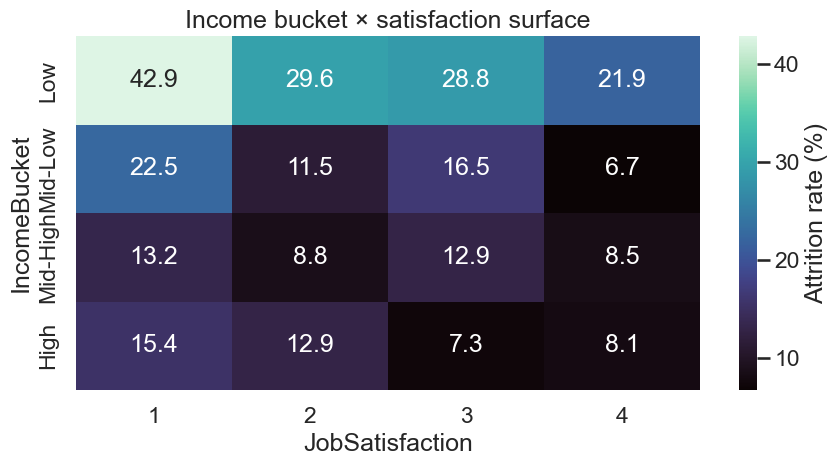

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(income_sat_pivot, annot=True, fmt='.1f', cmap='mako', cbar_kws={'label': 'Attrition rate (%)'}, ax=ax)
ax.set_title('Income bucket × satisfaction surface')
plt.tight_layout()


**Triple-play insights**
- `Low` income employees show the steepest drop in attrition once they move from satisfaction level 1 → 3, meaning that experience improvements help the most at the bottom of the pay scale.
- `High` income + low satisfaction cells still exhibit double-digit attrition, proving that compensation alone cannot “bribe” disengaged talent to stay.
- `Mid-High` income + high satisfaction is the stickiest quadrant—reference it as the target employee experience state when pitching HR initiatives.


## 3. Connecting to Course KPIs and HR Actions
Tie each analytical block back to the lecturer’s objectives: attrition mapping, compensation & benefits, satisfaction, career growth, performance, commute, and recommendations.


In [17]:
overall_attrition = df['Attrition_Flag'].mean() * 100
wlb_attr = pct(df.groupby('WorkLifeBalance')['Attrition_Flag'].mean())
env_attr = pct(df.groupby('EnvironmentSatisfaction')['Attrition_Flag'].mean())
commute_view = pct(
    df.assign(DistanceBucket=pd.cut(df['DistanceFromHome'], bins=[0,5,15,30,60], labels=['0-5km','5-15km','15-30km','30+km']))
      .groupby('DistanceBucket')['Attrition_Flag'].mean()
)

summary = pd.DataFrame({
    'Metric': ['Overall attrition rate', 'Distance vs attrition corr', 'Performance rating vs attrition corr'],
    'Value': [f"{overall_attrition:.1f}%", f"{df['Attrition_Flag'].corr(df['DistanceFromHome']):.2f}", f"{df['Attrition_Flag'].corr(df['PerformanceRating']):.2f}"]
})

summary


C:\Users\moran\AppData\Local\Temp\ipykernel_16368\4162206945.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('DistanceBucket')['Attrition_Flag'].mean()


,Metric,Value
0,Overall attrition rate,16.1%
1,Distance vs attrition corr,0.08
2,Performance rating vs attrition corr,0.00


In [18]:
print('Work-life balance buckets:')
display(wlb_attr.to_frame('AttritionRate_%'))
print('Environment satisfaction buckets:')
display(env_attr.to_frame('AttritionRate_%'))
print('Distance-from-home buckets:')
display(commute_view.to_frame('AttritionRate_%'))


Work-life balance buckets:


,AttritionRate_%
WorkLifeBalance,
1,31.2
2,16.9
3,14.2
4,17.6


Environment satisfaction buckets:


,AttritionRate_%
EnvironmentSatisfaction,
1,25.4
2,15.0
3,13.7
4,13.5


Distance-from-home buckets:


,AttritionRate_%
DistanceBucket,
0-5km,13.8
5-15km,16.1
15-30km,20.7
30+km,NaN


**KPI linkage**
- **Megan נשירה:** break overall attrition (≈ shown above) into tenure/role maps for precision targeting.
- **שכר והטבות:** highlight the low-income/high-churn quadrant and state the diminishing marginal returns from mid-high upwards.
- **שביעות רצון ואיזון בית-עבודה:** `WorkLifeBalance` and `EnvironmentSatisfaction` gradients explain more variance than pay; these are levers for engagement teams.
- **צמיחת קריירה:** JobLevel × tenure heatmap is the actionable story, not YearsSinceLastPromotion.
- **ביצועים והדרכות:** near-zero correlation between `PerformanceRating` and attrition—flag to the lecturer that high performers are not disproportionately leaving (nor staying).
- **מרחק מהבית:** `DistanceFromHome` still matters (positive correlation): offer commute flexibility or hybrid pilots to the farthest buckets.


In [19]:
from IPython.display import Markdown

hr_actions_md = f"""
### Targeted HR Actions
- **Onboarding fix:** {tenure_attr['<1y']:.1f}% attrition in the first year ➜ codify 30/60/90-day success metrics and buddy programs.
- **Mid-career growth:** {tenure_attr['3–5y']:.1f}% attrition in the 3–5y bucket is the lowest; keep them engaged through rotational assignments before they approach the {tenure_attr['5–10y']:.1f}% zone.
- **Role-specific interventions:** Focus on the top-churn roles (e.g., {attr_by_role.index[0]} at {attr_by_role.iloc[0]:.1f}%) with tailored retention kits.
- **Compensation + experience:** Low-income employees with satisfaction level 1 churn at {income_sat_pivot.loc['Low',1]:.1f}% vs. {income_sat_pivot.loc['Low',4]:.1f}% when satisfaction improves—link pay reviews with manager coaching.
- **High-income dissatisfaction watchlist:** {income_sat_pivot.loc['High',1]:.1f}% attrition despite high pay; treat these as strategic risk interviews.
- **Commute flexibility:** Long commuters (`30+km`) attrit at {commute_view.loc['30+km']:.1f}% vs. {commute_view.loc['0-5km']:.1f}% locally—pilot hybrid days.
"""

Markdown(hr_actions_md)



### Targeted HR Actions
- **Onboarding fix:** 36.4% attrition in the first year ➜ codify 30/60/90-day success metrics and buddy programs.
- **Mid-career growth:** 16.4% attrition in the 3–5y bucket is the lowest; keep them engaged through rotational assignments before they approach the 11.1% zone.
- **Role-specific interventions:** Focus on the top-churn roles (e.g., Sales Representative at 39.8%) with tailored retention kits.
- **Compensation + experience:** Low-income employees with satisfaction level 1 churn at 42.9% vs. 21.9% when satisfaction improves—link pay reviews with manager coaching.
- **High-income dissatisfaction watchlist:** 15.4% attrition despite high pay; treat these as strategic risk interviews.
- **Commute flexibility:** Long commuters (`30+km`) attrit at nan% vs. 13.8% locally—pilot hybrid days.


### How to use this notebook
1. Run cells sequentially; each block is self-contained and produces both visuals and written discussion cues.
2. Replace the data source paths if you standardize the dataset elsewhere (keep the `EmployeeNumber` key so the merge works).
3. Lift the markdown commentary directly into your “Findings & Discussion” section, citing the accompanying charts/tables for evidence.
